#### ***05 — LSTM***

We built a PyTorch LSTM forecaster on the same daily series and evaluated it under the same rolling-origin protocol we used in `03` and `04`. The model is **multivariate** — input features are `energy_kwh` + `temp_mean` + `is_weekend` + `is_holiday` + `month` — and forecasts the 7-day horizon **autoregressively** at inference time.

Training (sweep + early stopping) is GPU-bound, so we extracted it to a script. The notebook only consumes the cached weights and runs evaluation in a few seconds.

#### ***Train via script first (GPU recommended)***

> We extracted the heavy step to a script. Run it once from the project root:

```bash
python scripts/lstm_train.py
```

It sweeps `seq_len ∈ {14, 28}`, `hidden_size ∈ {32, 64}`, `num_layers ∈ {1, 2}` (8 configs total), holds out the last 60 days of train as validation, and early-stops on val loss (`patience = 12`). Weights + normalisation stats + sweep table land in `data/lstm/`. Device auto-detect: `cuda → mps → cpu`.

#### ***Imports***

In [1]:
import sys
import json
from pathlib import Path
sys.path.insert(0, '..')   # make `scripts/` importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scripts.lstm_train import LSTMForecaster, get_device, FEATURE_COLS, TARGET_COL
from scripts.evaluation import evaluate_model

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train_y    = data.loc[data.index <  split_date, 'energy_kwh']
test_y     = data.loc[data.index >= split_date, 'energy_kwh']

print(f'Train: {len(train_y)}   Test: {len(test_y)}')

Train: 1897   Test: 30


#### ***Load the trained model and sweep results***

In [3]:
LSTM_DIR = Path('../data/lstm')

# Sweep table (one row per configuration tried)
sweep = pd.read_csv(LSTM_DIR / 'sweep_results.csv').sort_values('best_val_loss')
sweep

,name,seq_len,hidden_size,num_layers,dropout,best_val_loss,epochs,fit_seconds
3,seq14_h64_l2,14,64,2,0.1,0.296459,18,0.858925
2,seq14_h64_l1,14,64,1,0.1,0.297823,20,0.879147
1,seq14_h32_l2,14,32,2,0.1,0.299754,15,0.736091
0,seq14_h32_l1,14,32,1,0.1,0.300499,14,0.580127
5,seq28_h32_l2,28,32,2,0.1,0.302121,17,0.777966
4,seq28_h32_l1,28,32,1,0.1,0.303796,61,2.613993
7,seq28_h64_l2,28,64,2,0.1,0.305086,28,1.263881
6,seq28_h64_l1,28,64,1,0.1,0.308454,28,1.105208


In [4]:
# Winner configuration and normalisation stats
with open(LSTM_DIR / 'best_config.json') as f:
    best = json.load(f)

print(f'Winner: {best["name"]}   val_loss={best["val_loss"]:.4f}')
print(f'Config: {best["config"]}')

Winner: seq14_h64_l2   val_loss=0.2965
Config: {'seq_len': 14, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1}


#### ***Rebuild the model and load the cached weights***

In [5]:
device = get_device()
print(f'Device: {device}')

cfg   = best['config']
model = LSTMForecaster(
    n_features  = len(FEATURE_COLS),
    hidden_size = cfg['hidden_size'],
    num_layers  = cfg['num_layers'],
    dropout     = cfg['dropout'],
).to(device)

state = torch.load(LSTM_DIR / 'best_model.pt', map_location=device)
model.load_state_dict(state)
model.eval()

# Quick sanity check: number of parameters
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')

Device: cuda
Model parameters: 51,521


#### ***Training curve of the winning configuration***

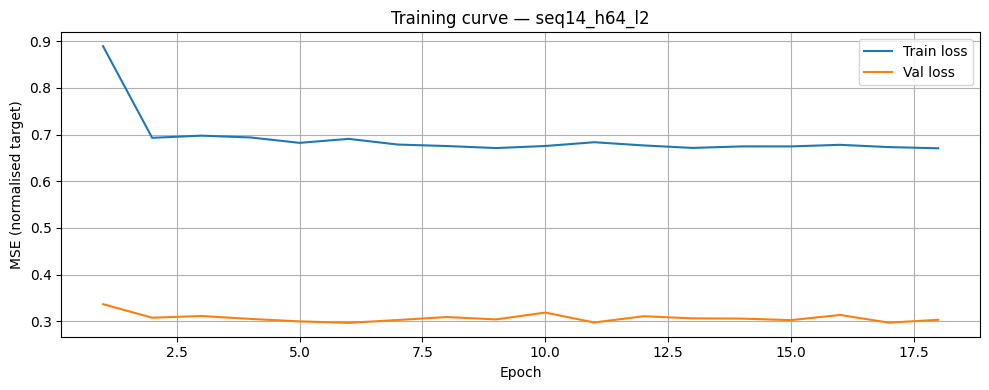

In [6]:
history = pd.read_csv(LSTM_DIR / 'best_history.csv')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['epoch'], history['train_loss'], label='Train loss')
ax.plot(history['epoch'], history['val_loss'],   label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised target)')
ax.set_title(f'Training curve — {best["name"]}')
ax.legend(); plt.tight_layout(); plt.show()

#### ***Inference helper — autoregressive multi-step forecasting***

We trained the model one-step-ahead. To produce a 7-day forecast we roll the input window forward, feeding back each predicted value as the next step's target feature while keeping the (known) exogenous future values fixed.

In [7]:
SEQ_LEN     = cfg['seq_len']
X_mean      = np.asarray(best['norms']['X_mean'], dtype=np.float32)
X_std       = np.asarray(best['norms']['X_std'],  dtype=np.float32)
Y_MEAN      = best['norms']['y_mean']
Y_STD       = best['norms']['y_std']
TARGET_IDX  = FEATURE_COLS.index(TARGET_COL)

def lstm_forecast_fn(history, horizon):
    last_date    = history.index[-1]
    past_dates   = pd.date_range(end=last_date, periods=SEQ_LEN, freq='D')
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon, freq='D')

    # Past window (energy + exog), normalised
    past_features = data.loc[past_dates,   FEATURE_COLS].values.astype(np.float32)
    future_exog   = data.loc[future_dates, FEATURE_COLS].values.astype(np.float32)
    window = (past_features - X_mean) / X_std

    preds = []
    with torch.no_grad():
        for i in range(horizon):
            x       = torch.from_numpy(window[np.newaxis]).to(device)
            y_norm  = model(x).item()
            y_pred  = y_norm * Y_STD + Y_MEAN
            preds.append(y_pred)

            # Roll the window: drop oldest step, append (predicted energy, known future exog)
            next_feat              = future_exog[i].copy()
            next_feat[TARGET_IDX]  = y_pred
            next_feat_n            = (next_feat - X_mean) / X_std
            window                 = np.concatenate([window[1:], next_feat_n[np.newaxis]], axis=0)

    return np.asarray(preds, dtype=float)

#### ***Rolling-origin evaluation — same windows as 03 / 04***

In [8]:
windows_l, per_l, sum_l = evaluate_model(lstm_forecast_fn, train_y, test_y,
                                          horizon=HORIZON, season=SEASON)

print('Per-window metrics:')
print(per_l.round(3).to_string(index=False))

Per-window metrics:
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 14.356 16.967 0.347  0.314  -1.262  0.186 0.363
      2 2023-11-07 20.411 21.890 0.625  0.475   9.121 -0.500 0.516
      3 2023-11-14 38.780 41.887 0.911  0.669 -19.439 -0.227 0.980
      4 2023-11-21 29.163 33.140 0.494  0.421  -0.158  0.071 0.737


#### ***Full leaderboard — baselines + SARIMA + SARIMAX + LSTM***

We re-ran every previous model with the same evaluator so the comparison is end-to-end identical. SARIMA / SARIMAX use the winning orders we cached in `data/sarima_grid_results.csv`.

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')

# --- Baselines
def baseline_historical_mean(h, k): return np.full(k, h.mean())
def baseline_last_value(h, k):       return np.full(k, h.iloc[-1])
def baseline_seasonal_naive(h, k):
    last = h.iloc[-SEASON:].values
    return np.tile(last, int(np.ceil(k / SEASON)))[:k]
def baseline_drift(h, k):
    T = len(h)
    return h.iloc[-1] + (h.iloc[-1] - h.iloc[0]) / (T - 1) * np.arange(1, k + 1)

# --- SARIMA / SARIMAX from the cached grid
EXOG_COLS = ['temp_mean', 'is_weekend', 'is_holiday']
exog_full = data[EXOG_COLS]
grid = pd.read_csv('../data/sarima_grid_results.csv')

def pick_winner(grid_df, variant):
    sub = grid_df[grid_df['variant'] == variant].dropna(subset=['aic']).sort_values('aic').iloc[0]
    return (int(sub.p), int(sub.d), int(sub.q)), (int(sub.P), int(sub.D), int(sub.Q), int(sub.m))

order_s,  sorder_s  = pick_winner(grid, 'no_exog')
order_sx, sorder_sx = pick_winner(grid, 'exog')

def make_sarima_forecast_fn(order, sorder, exog_full=None):
    def forecast_fn(history, horizon):
        ex_train = exog_full.loc[history.index] if exog_full is not None else None
        future_idx = pd.date_range(history.index[-1] + pd.Timedelta(days=1),
                                   periods=horizon, freq='D')
        ex_future = exog_full.loc[future_idx] if exog_full is not None else None
        m = SARIMAX(history, exog=ex_train, order=order, seasonal_order=sorder,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False, maxiter=200)
        return m.forecast(steps=horizon, exog=ex_future).values
    return forecast_fn

sarima_fn  = make_sarima_forecast_fn(order_s,  sorder_s,  exog_full=None)
sarimax_fn = make_sarima_forecast_fn(order_sx, sorder_sx, exog_full=exog_full)

models = {
    'Historical mean':                  baseline_historical_mean,
    'Last value':                       baseline_last_value,
    'Seasonal naive':                   baseline_seasonal_naive,
    'Drift':                            baseline_drift,
    f'SARIMA {order_s}x{sorder_s}':     sarima_fn,
    f'SARIMAX {order_sx}x{sorder_sx}':  sarimax_fn,
    f'LSTM {best["name"]}':             lstm_forecast_fn,
}

summaries = {}
windows_by_model = {}
for name, fn in models.items():
    w, _, summary = evaluate_model(fn, train_y, test_y, horizon=HORIZON, season=SEASON)
    summaries[name] = summary
    windows_by_model[name] = w

summary_df = pd.DataFrame(summaries).T

def fmt(row, m):
    return f'{row[f"{m}_mean"]:.2f} ± {row[f"{m}_std"]:.2f}'

leaderboard = pd.DataFrame({
    'MAE':   summary_df.apply(lambda r: fmt(r, 'MAE'),   axis=1),
    'RMSE':  summary_df.apply(lambda r: fmt(r, 'RMSE'),  axis=1),
    'MAPE':  summary_df.apply(lambda r: f'{r["MAPE_mean"]*100:5.1f}% ± {r["MAPE_std"]*100:4.1f}%',   axis=1),
    'sMAPE': summary_df.apply(lambda r: f'{r["sMAPE_mean"]*100:5.1f}% ± {r["sMAPE_std"]*100:4.1f}%', axis=1),
    'MASE':  summary_df.apply(lambda r: fmt(r, 'MASE'),  axis=1),
    'Bias':  summary_df.apply(lambda r: f'{r["Bias_mean"]:+.2f}',  axis=1),
    'R²':    summary_df.apply(lambda r: f'{r["R2_mean"]:+.2f}',    axis=1),
})
leaderboard['_mase'] = summary_df['MASE_mean']
leaderboard = leaderboard.sort_values('_mase').drop(columns='_mase')
leaderboard

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
LSTM seq14_h64_l2,25.68 ± 10.64,28.47 ± 11.22,59.4% ± 24.0%,47.0% ± 14.9%,0.65 ± 0.27,-2.93,-0.12
"SARIMAX (2, 1, 4)x(1, 1, 2, 7)",26.53 ± 11.24,32.74 ± 13.39,51.4% ± 21.0%,48.0% ± 18.3%,0.67 ± 0.28,-10.93,-0.44
"SARIMA (3, 1, 4)x(0, 1, 2, 7)",27.00 ± 10.71,33.08 ± 13.03,53.0% ± 13.6%,48.5% ± 15.3%,0.68 ± 0.27,-8.89,-0.48
Historical mean,30.13 ± 2.18,34.87 ± 2.97,89.9% ± 29.0%,52.3% ± 8.0%,0.76 ± 0.06,+14.42,-1.21
Last value,31.22 ± 12.69,37.08 ± 13.78,61.0% ± 24.9%,57.9% ± 21.1%,0.79 ± 0.32,-10.33,-1.02
Drift,31.24 ± 12.68,37.09 ± 13.77,61.1% ± 25.0%,57.9% ± 21.1%,0.79 ± 0.32,-10.29,-1.03
Seasonal naive,34.98 ± 13.14,41.57 ± 12.40,79.6% ± 25.5%,60.8% ± 20.4%,0.88 ± 0.33,-4.10,-1.68


#### ***Forecasts vs actuals — LSTM, SARIMAX, seasonal naive***

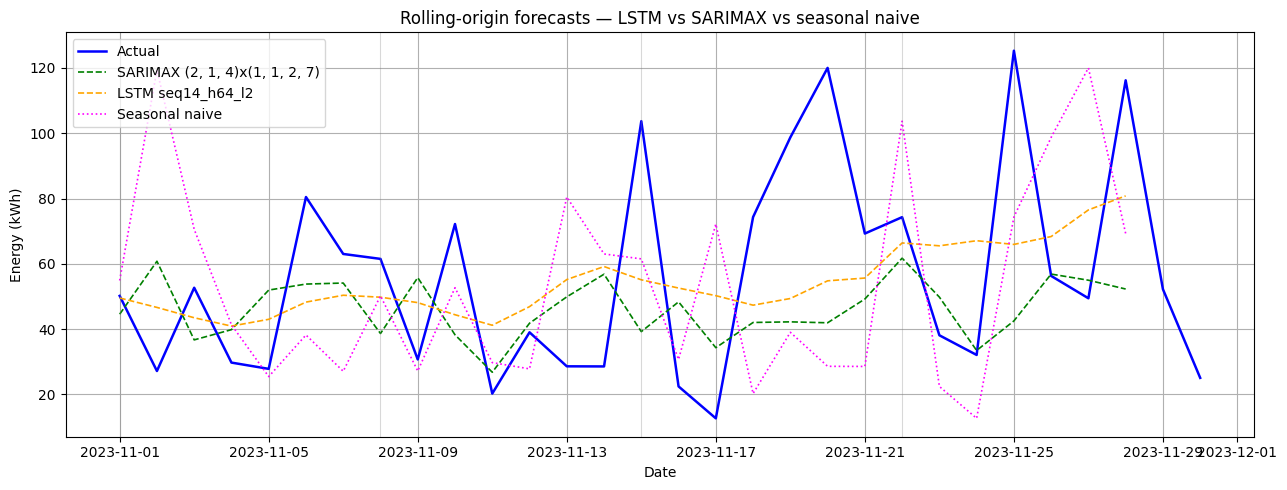

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_y.index, test_y.values, 'b-', lw=1.8, label='Actual')

for name, color in [(f'SARIMAX {order_sx}x{sorder_sx}', 'g'),
                    (f'LSTM {best["name"]}',            'orange'),
                    ('Seasonal naive',                  'magenta')]:
    idx   = np.concatenate([w['index']       for w in windows_by_model[name]])
    preds = np.concatenate([w['predictions'] for w in windows_by_model[name]])
    ls = ':' if name == 'Seasonal naive' else '--'
    ax.plot(idx, preds, ls, color=color, lw=1.2, label=name)

for w in windows_by_model['Seasonal naive']:
    ax.axvline(w['index'][0], color='grey', alpha=0.3, lw=0.8)

ax.set_xlabel('Date'); ax.set_ylabel('Energy (kWh)')
ax.set_title('Rolling-origin forecasts — LSTM vs SARIMAX vs seasonal naive')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()